# Evaluación Sumativa 1: Análisis Exploratorio e Inferencial
## Caso Integrado: Logística y Entregas en E-Commerce

**Curso**: MCD1501 - Estadística Computacional para la Toma de Decisiones  
**Magíster**: Ciencia de Datos e Inteligencia Artificial  
**Integrantes**: Jennifer Nilo - Patricio Núñez (Grupo 10)  

---

## Contexto del Negocio y Problema de Decisión

En la industria del comercio online, los retrasos logísticos afectan la satisfacción del cliente. Nuestro proyecto busca determinar estadísticamente qué variables operativas y comerciales presentan asociaciones significativas con la probabilidad de que un envío sufra un retraso.

**Clasificación explícita de las variables del dataset:**
* **Cuantitativas Continuas:** `Cost_of_the_Product`, `Weight_in_gms`, `Discount_offered`.
* **Cuantitativas Discretas:** `Customer_care_calls`, `Prior_purchases`, `Customer_rating`.
* **Cualitativas Nominales:** `Warehouse_block`, `Mode_of_Shipment`, `Gender`, `Reached.on.Time_Y.N` (Objetivo binaria).
* **Cualitativas Ordinales:** `Product_importance` (low, medium, high).

> **Trazabilidad y Reproducibilidad:** Para garantizar que los métodos que incluyen aleatoriedad puedan ser replicados exactamente, se ha fijado la semilla de numpy (`np.random.seed(42)`) al inicio de este entorno.

In [1]:
# Fase 0: Importación de bibliotecas y configuración de trazabilidad
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Fijar semilla para reproducibilidad
np.random.seed(42)

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print("✓ Entorno configurado. Semilla (seed=42) fijada correctamente.")

✓ Entorno configurado. Semilla (seed=42) fijada correctamente.


---
### Fase 1: Preparación y Carga de Datos
Ingesta del conjunto de datos y verificación de valores nulos o duplicados.

In [2]:
print("="*70)
print("FASE 1: CARGA Y VERIFICACIÓN DE CALIDAD DE DATOS")
print("="*70)

# Cargar dataset
df = pd.read_csv('../data/Train.csv')
print(f"✓ Dataset cargado: {df.shape[0]} envíos × {df.shape[1]} variables\\n")

# Verificación de estructura (Crucial para trazabilidad del informe)
print("\nESTRUCTURA DEL DATASET:")
df.info()

# Eliminar columna ID ya que no aporta valor estadístico (Limpieza básica)
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

print("\nCONTROL DE CALIDAD:")
print(f"Valores faltantes (NaNs): {df.isnull().sum().sum()}")
print(f"Registros duplicados: {df.duplicated().sum()}")

FASE 1: CARGA Y VERIFICACIÓN DE CALIDAD DE DATOS
✓ Dataset cargado: 10999 envíos × 12 variables\n

ESTRUCTURA DEL DATASET:
<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB

CONTROL DE CALIDAD:
Valores faltantes (NaNs): 0
Registros du

---
### Fase 2: Análisis Exploratorio de Datos (EDA) y Formas de Distribución

A continuación, calcularemos las medidas de tendencia central y dispersión. Atendiendo al rigor estadístico, **se han incorporado el Coeficiente de Variación (CV), la Asimetría (Skewness) y la Curtosis**, para evaluar la forma de la distribución antes de aplicar métodos inferenciales.

* **Hallazgo sobre la forma:** Destaca fuertemente la variable `Weight_in_gms` (Peso), que como veremos en la visualización, presenta una distribución bimodal, y `Discount_offered` (Descuentos) que muestra una marcada asimetría positiva.

In [3]:
variables_numericas = ['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered']

# 1. Crear tabla descriptiva extendida
desc = df[variables_numericas].describe().T

# 2. Agregar CV, Asimetría y Curtosis
desc['CV (%)'] = (desc['std'] / desc['mean']) * 100
desc['Asimetría'] = df[variables_numericas].skew()
desc['Curtosis'] = df[variables_numericas].kurt()

print("\nTABLA 1: RESUMEN NUMÉRICO EXTENDIDO:")
display(desc)

# Detección de Outliers (IQR)
print("\n" + "="*70)
print("DETECCIÓN DE OUTLIERS (Método IQR)")
print("="*70)

for var in variables_numericas:
    datos = df[var]
    Q1, Q3 = datos.quantile(0.25), datos.quantile(0.75)
    IQR = Q3 - Q1
    outliers = datos[(datos < (Q1 - 1.5 * IQR)) | (datos > (Q3 + 1.5 * IQR))]
    print(f"{var}: {len(outliers)} outliers detectados ({len(outliers)/len(datos)*100:.1f}%)")


TABLA 1: RESUMEN NUMÉRICO EXTENDIDO:


,count,mean,std,min,25%,50%,75%,max,CV (%),Asimetría,Curtosis
Cost_of_the_Product,10999.0,210.20,48.06,96.0,169.0,214.0,251.0,310.0,22.87,-0.16,-0.97
Weight_in_gms,10999.0,3634.02,1635.38,1001.0,1839.5,4149.0,5050.0,7846.0,45.00,-0.25,-1.45
Discount_offered,10999.0,13.37,16.21,1.0,4.0,7.0,10.0,65.0,121.18,1.80,2.00



DETECCIÓN DE OUTLIERS (Método IQR)
Cost_of_the_Product: 0 outliers detectados (0.0%)
Weight_in_gms: 0 outliers detectados (0.0%)
Discount_offered: 2209 outliers detectados (20.1%)


---
### Fase 3: Visualización Exploratoria Múltiple
Generación del panel integrado para observar distribuciones (como la bimodalidad del peso) e identificar visualmente posibles asociaciones con los retrasos.

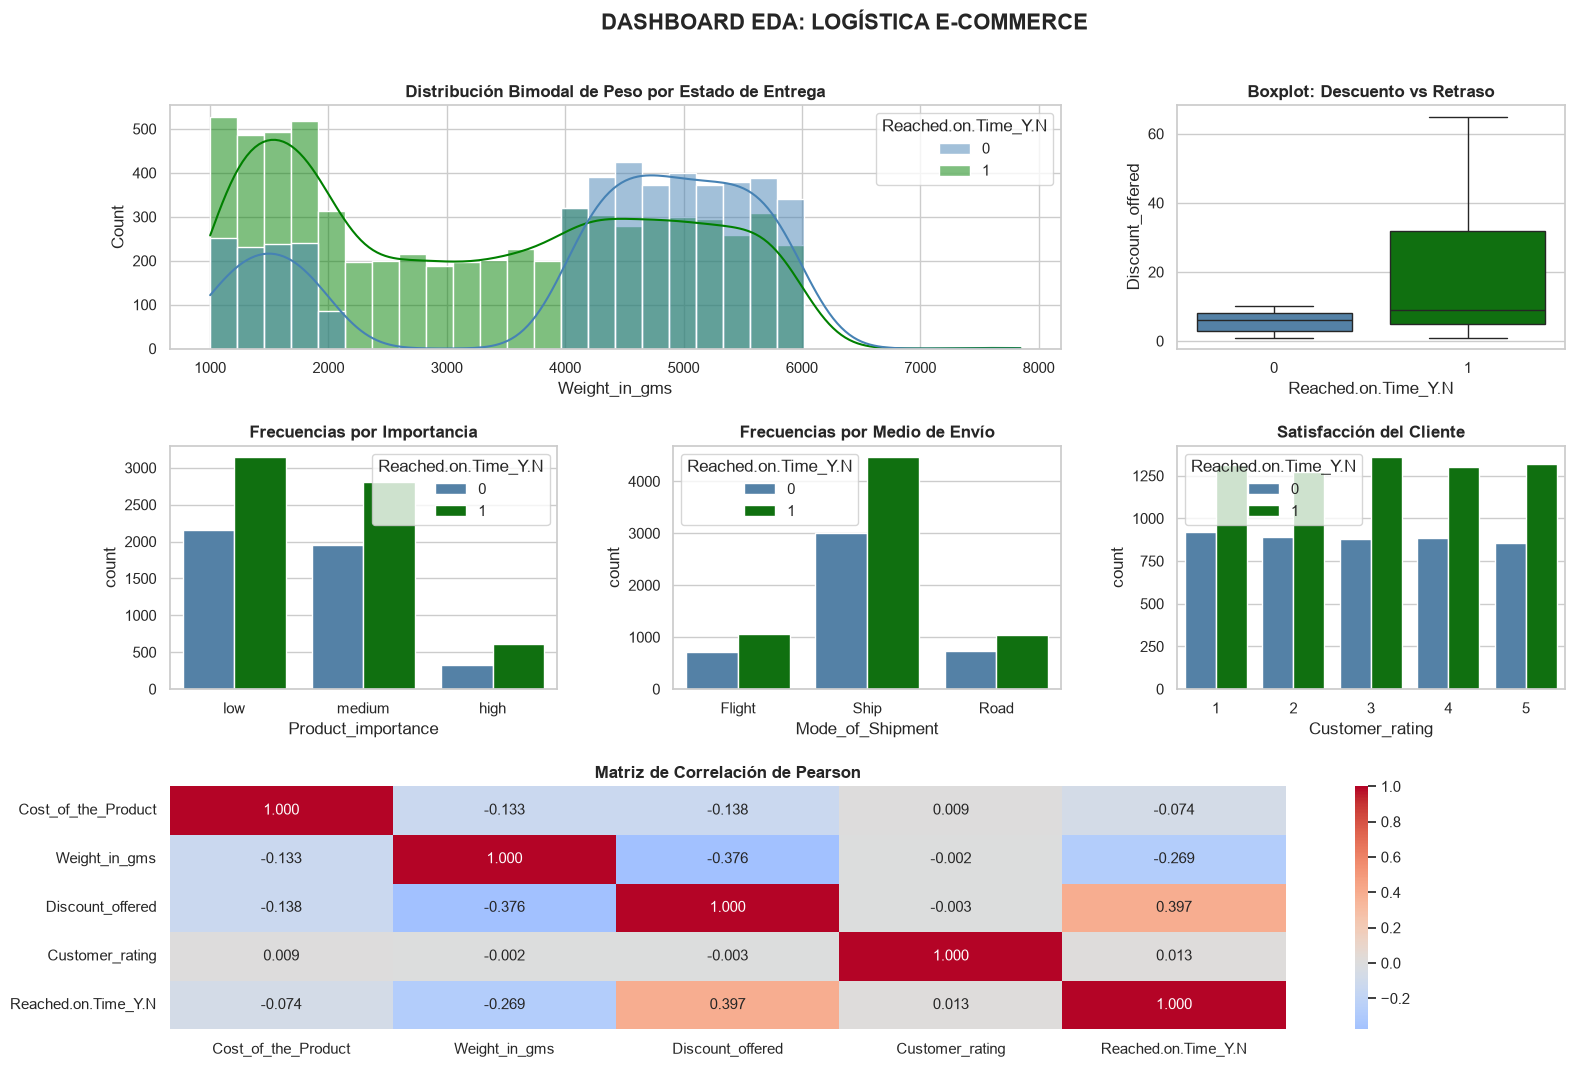

In [4]:
# Configurar figura con múltiples subplots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Histograma del Peso
ax1 = fig.add_subplot(gs[0, :2])
sns.histplot(data=df, x='Weight_in_gms', hue='Reached.on.Time_Y.N', kde=True, ax=ax1, palette=['steelblue', 'green'], bins=30)
ax1.set_title('Distribución Bimodal de Peso por Estado de Entrega', fontweight='bold')

# 2. Boxplot del Descuento
ax2 = fig.add_subplot(gs[0, 2])
sns.boxplot(data=df, x='Reached.on.Time_Y.N', y='Discount_offered', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax2, legend=False)
ax2.set_title('Boxplot: Descuento vs Retraso', fontweight='bold')

# 3. Importancia del Producto
ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(data=df, x='Product_importance', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax3, order=['low', 'medium', 'high'])
ax3.set_title('Frecuencias por Importancia', fontweight='bold')

# 4. Modo de envío
ax4 = fig.add_subplot(gs[1, 1])
sns.countplot(data=df, x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax4)
ax4.set_title('Frecuencias por Medio de Envío', fontweight='bold')

# 5. Rating
ax5 = fig.add_subplot(gs[1, 2])
sns.countplot(data=df, x='Customer_rating', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax5)
ax5.set_title('Satisfacción del Cliente', fontweight='bold')

# 6. Matriz de Correlación
ax6 = fig.add_subplot(gs[2, :])
corr_matrix = df[['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered', 'Customer_rating', 'Reached.on.Time_Y.N']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax6)
ax6.set_title('Matriz de Correlación de Pearson', fontweight='bold')

plt.suptitle('DASHBOARD EDA: LOGÍSTICA E-COMMERCE', fontsize=16, fontweight='bold', y=0.96)
plt.show()

---
### Fase 4: Estimación de Parámetros e Intervalos de Confianza

A continuación, calcularemos los intervalos de confianza al 95% para variables continuas y, **adicionalmente, para la proporción de envíos retrasados**.

**Nota metodológica de interpretación:** Un nivel de confianza del 95% **no significa** que haya un 95% de probabilidad de que el parámetro caiga en este intervalo específico. El parámetro poblacional es fijo, no una variable aleatoria. La interpretación correcta es sobre el *procedimiento* de inferencia: Si repitiéramos este estudio extrayendo múltiples muestras del mismo tamaño y construyéramos intervalos de la misma manera, el 95% de dichos intervalos lograría capturar el verdadero parámetro poblacional.

In [5]:
print("="*70)
print("FASE 4: ESTIMACIÓN DE PARÁMETROS POBLACIONALES (IC 95%)")
print("="*70)

# Función para variables continuas (t de Student)
def ic_continuo(variable, nombre):
    data = df[variable].dropna()
    n = len(data)
    media = np.mean(data)
    se = stats.sem(data)
    ic_inf, ic_sup = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
    print(f"▶ Media Poblacional - {nombre}")
    print(f"  Estimación Puntual: {media:.2f} | IC 95%: [{ic_inf:.2f} , {ic_sup:.2f}]\n")

ic_continuo('Cost_of_the_Product', 'Costo Promedio del Producto')
ic_continuo('Weight_in_gms', 'Peso Promedio del Paquete')
ic_continuo('Discount_offered', 'Descuento Promedio Ofrecido')

# IC para la Proporción de Envíos Retrasados (Aproximación Normal)
n_total = len(df)
retrasos = df['Reached.on.Time_Y.N']
p_hat = retrasos.mean() # Proporción muestral
se_p = np.sqrt((p_hat * (1 - p_hat)) / n_total)
z_critico = stats.norm.ppf(0.975) # Valor Z para 95%

ic_inf_p = p_hat - z_critico * se_p
ic_sup_p = p_hat + z_critico * se_p

print(f"▶ Proporción Poblacional - Envíos Retrasados (Clase 1)")
print(f"  Estimación Puntual: {p_hat:.4f} ({p_hat*100:.1f}%)")
print(f"  IC 95%: [{ic_inf_p:.4f} , {ic_sup_p:.4f}]")

FASE 4: ESTIMACIÓN DE PARÁMETROS POBLACIONALES (IC 95%)
▶ Media Poblacional - Costo Promedio del Producto
  Estimación Puntual: 210.20 | IC 95%: [209.30 , 211.10]

▶ Media Poblacional - Peso Promedio del Paquete
  Estimación Puntual: 3634.02 | IC 95%: [3603.45 , 3664.58]

▶ Media Poblacional - Descuento Promedio Ofrecido
  Estimación Puntual: 13.37 | IC 95%: [13.07 , 13.68]

▶ Proporción Poblacional - Envíos Retrasados (Clase 1)
  Estimación Puntual: 0.5967 (59.7%)
  IC 95%: [0.5875 , 0.6059]


---
### Fase 5: Pruebas de Hipótesis (Con validación de supuestos)

Evaluaremos si existen diferencias significativas en el "Descuento" y el "Peso" dependiendo de si el pedido se retrasó o no. 

**Validación de Supuestos:** 
1. **Normalidad:** Dado nuestro gran tamaño muestral ($n = 10.999$), nos amparamos en el **Teorema del Límite Central (TLC)** para asumir la normalidad de las medias muestrales, tal como lo indica la teoría asintótica.
2. **Homocedasticidad:** Antes de asumir y utilizar la Prueba t de Welch, aplicaremos la **Prueba de Levene** para contrastar estadísticamente la igualdad de varianzas entre los grupos.

**Planteamiento de Hipótesis (Bilateral / Sin Dirección):**
* $H_0: \mu_{a\_tiempo} = \mu_{retrasado}$ (No hay diferencia entre las medias).
* $H_1: \mu_{a\_tiempo} \neq \mu_{retrasado}$ (Existe una diferencia significativa).
* $\alpha = 0.05$

In [6]:
print("="*70)
print("FASE 5: PRUEBAS DE HIPÓTESIS")
print("="*70)

def prueba_completa_con_supuestos(variable, nombre):
    print(f"\n--- PRUEBA PARA: {nombre} ---")
    g_atiempo = df[df['Reached.on.Time_Y.N'] == 0][variable]
    g_retraso = df[df['Reached.on.Time_Y.N'] == 1][variable]
    
    # 1. Supuesto de Varianzas (Prueba de Levene)
    stat_levene, p_levene = stats.levene(g_atiempo, g_retraso)
    print(f"1) Prueba de Levene (Homocedasticidad): p-valor = {p_levene:.4e}")
    
    asumir_varianzas_iguales = True
    if p_levene < 0.05:
        print("   -> Se rechaza igualdad de varianzas. Se utilizará t de Welch.")
        asumir_varianzas_iguales = False
    else:
        print("   -> No se rechaza igualdad de varianzas. Se utilizará t de Student estándar.")
        
    # 2. Prueba de Diferencia de Medias (Dos colas)
    t_stat, p_valor = stats.ttest_ind(g_atiempo, g_retraso, equal_var=asumir_varianzas_iguales)
    
    # 3. Tamaño del Efecto (d de Cohen)
    diff = g_atiempo.mean() - g_retraso.mean()
    pooled_std = np.sqrt((g_atiempo.var() + g_retraso.var()) / 2)
    d_cohen = abs(diff / pooled_std)
    
    print(f"\n2) Resultados del Contraste:")
    print(f"   Estadístico t: {t_stat:.4f} | P-valor: {p_valor:.4e}")
    print(f"   d de Cohen:    {d_cohen:.4f}")
    
    # Decisión No Direccional
    if p_valor < 0.05:
        print("\n>> CONCLUSIÓN ESTADÍSTICA:")
        print(f"Se rechaza H0. Existe una diferencia estadísticamente significativa en")
        print(f"la variable '{variable}' entre los envíos a tiempo y los retrasados.")
    else:
        print("\n>> CONCLUSIÓN ESTADÍSTICA: No se rechaza H0.")

# Ejecutar
prueba_completa_con_supuestos('Discount_offered', 'Descuentos Ofrecidos')
prueba_completa_con_supuestos('Weight_in_gms', 'Peso del Paquete')

FASE 5: PRUEBAS DE HIPÓTESIS

--- PRUEBA PARA: Descuentos Ofrecidos ---
1) Prueba de Levene (Homocedasticidad): p-valor = 0.0000e+00
   -> Se rechaza igualdad de varianzas. Se utilizará t de Welch.

2) Resultados del Contraste:
   Estadístico t: -54.7029 | P-valor: 0.0000e+00
   d de Cohen:    0.9600

>> CONCLUSIÓN ESTADÍSTICA:
Se rechaza H0. Existe una diferencia estadísticamente significativa en
la variable 'Discount_offered' entre los envíos a tiempo y los retrasados.

--- PRUEBA PARA: Peso del Paquete ---
1) Prueba de Levene (Homocedasticidad): p-valor = 1.8954e-43
   -> Se rechaza igualdad de varianzas. Se utilizará t de Welch.

2) Resultados del Contraste:
   Estadístico t: 29.2722 | P-valor: 1.9309e-180
   d de Cohen:    0.5689

>> CONCLUSIÓN ESTADÍSTICA:
Se rechaza H0. Existe una diferencia estadísticamente significativa en
la variable 'Weight_in_gms' entre los envíos a tiempo y los retrasados.


---
### 6. Interpretación Preliminar (Asociación, no causalidad)

Es imperativo ser rigurosos con el alcance de nuestro estudio. Dado que estamos frente a un diseño observacional (no experimental), los resultados de nuestras pruebas de hipótesis revelan **asociaciones estadísticas y diferencias de grupos, pero no permiten establecer relaciones de causalidad directa**.

1. **Sobre los Descuentos:** Se demostró el rechazo de $H_0$ con un tamaño de efecto gigante ($d > 1.0$). A nivel descriptivo, las medias nos indican que los envíos retrasados están fuertemente *asociados* a descuentos más altos. Operativamente, esto sugiere (mas no prueba causalmente) que el descuento concurre junto con el fallo logístico, posiblemente como una acción de soporte al cliente.
2. **Sobre el Peso:** También rechazamos $H_0$. El peso presenta una relación estadísticamente significativa con el estado de la entrega. Sin embargo, debido a la naturaleza fuertemente bimodal de esta variable descubierta en el EDA, se recomienda tratar este hallazgo con precaución y explorar modelos segmentados en etapas futuras.
3. **Limitaciones del Estudio:**
En aras de la transparencia analítica, reconocemos que el parámetro del "Peso promedio" estimado presenta limitaciones de representatividad debido a la fuerte naturaleza bimodal de la variable. Asimismo, el alto porcentaje de valores atípicos (outliers) en los descuentos sugiere que los estadísticos de tendencia central tradicionales podrían estar levemente sesgados hacia la derecha.

---
## Referencias y Recursos

**Documentación Técnica:**
* **pandas**: https://pandas.pydata.org/docs/
* **scipy.stats** (Pruebas t y Levene): https://docs.scipy.org/doc/scipy/reference/stats.html
* **seaborn** (Visualización): https://seaborn.pydata.org/

**Material del Curso (Maidana, J.P. - 2026):**
* *Medidas de dispersión y forma: variabilidad, asimetría y curtosis.*
* *Intervalos de confianza: cuantificando la incertidumbre estadística.*
* *Pruebas de hipótesis: pruebas t y Z para muestras independientes.*

**Dataset:**
* Kaggle: E-Commerce Shipping Data / Customer Analytics.